### 1. Problem Statement



Gold prices are highly dynamic and can be affected by economic conditions, market trends, inflation, interest rates, and other financial factors. Traditional prediction methods may struggle to capture the complex and nonlinear patterns present in historical gold-price data.

This project aims to develop a deep learning model for gold price forecasting using historical data from 2000 to 2026. The model will learn relationships in the historical data to predict future gold prices.

### 2. The  Dataset

The Gold Price Prediction Dataset (2000–2026) contains historical observations of gold prices over an extended period. The dataset can be used to analyze long-term trends, fluctuations, and patterns in the gold market.

2.1 Importing Libraries and Dataset from Kaggle

In [47]:
import kagglehub
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt

path = kagglehub.dataset_download("hayaalwizrah1/gold-price-prediction-dataset-20002026")
data = pd.read_csv(os.path.join(path, 'gold_data.csv'))

Using Colab cache for faster access to the 'gold-price-prediction-dataset-20002026' dataset.


In [2]:
data

,Date,Gold_Open,Gold_High,Gold_Low,Gold_Close,Gold_Volume,DXY,SP500,Oil,VIX,...,Daily_Return,RSI,MACD,MACD_Signal,MACD_Hist,BB_Upper,BB_Middle,BB_Lower,ATR,Target
0,2000-10-18,270.299988,270.299988,270.299988,270.299988,0.0,117.330002,1342.130005,33.549999,28.719999,...,-0.002951,44.027677,-0.811933,-0.890278,0.078346,277.007532,272.364998,267.722464,1.797421,270.100006
1,2000-10-19,270.100006,270.100006,270.100006,270.100006,1.0,116.940002,1388.760010,32.950001,25.090000,...,-0.000740,43.589968,-0.887787,-0.889780,0.001993,277.016104,272.354999,267.693893,1.683319,271.200012
2,2000-10-20,271.200012,271.200012,271.200012,271.200012,32.0,117.160004,1396.930054,34.299999,24.240000,...,0.004073,46.727258,-0.849350,-0.881694,0.032344,277.007681,272.325000,267.642319,1.641653,270.100006
3,2000-10-23,271.700012,271.700012,270.100006,270.100006,1.0,117.540001,1395.780029,33.730000,24.690001,...,-0.004056,44.086729,-0.897306,-0.884817,-0.012490,276.828986,272.125000,267.421014,1.638679,270.100006
4,2000-10-24,269.799988,270.100006,269.799988,270.100006,16.0,117.419998,1398.130005,33.369999,24.280001,...,0.000000,44.086729,-0.924653,-0.892784,-0.031869,276.643831,271.935001,267.226170,1.543060,266.200012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6463,2026-07-24,4067.600098,4068.000000,4067.600098,4067.600098,2.0,101.470001,7411.979980,89.309998,18.580000,...,0.005190,45.939508,-51.155755,-67.827557,16.671801,4168.248475,4067.690027,3967.131578,75.288296,4074.500000
6464,2026-07-27,4090.100098,4107.899902,4072.699951,4074.500000,36.0,101.510002,7413.180176,82.610001,18.670000,...,0.001696,46.480858,-46.768670,-63.615779,16.847110,4167.963146,4067.480029,3966.996913,72.789118,4036.300049
6465,2026-07-28,4025.699951,4036.300049,4025.699951,4036.300049,248.0,101.379997,7428.779785,79.260002,18.209999,...,-0.009375,43.862116,-45.845807,-60.061785,14.215978,4167.583695,4068.180029,3968.776364,71.075613,4034.699951
6466,2026-07-29,4018.100098,4034.699951,4017.899902,4034.699951,89664.0,100.800003,7316.149902,84.459999,20.660000,...,-0.000396,43.750924,-44.727951,-56.995018,12.267067,4167.227238,4068.770032,3970.312825,67.313080,4100.100098


### 3. EDA

Printing the shape of data

In [6]:
print("Shape:", data.shape)

Shape: (6468, 25)


checking the column names

In [12]:
print("Columns:", data.columns)

Columns: Index(['Date', 'Gold_Open', 'Gold_High', 'Gold_Low', 'Gold_Close',
       'Gold_Volume', 'DXY', 'SP500', 'Oil', 'VIX', 'Lag1', 'Lag7', 'MA7',
       'MA30', 'EMA20', 'Daily_Return', 'RSI', 'MACD', 'MACD_Signal',
       'MACD_Hist', 'BB_Upper', 'BB_Middle', 'BB_Lower', 'ATR', 'Target'],
      dtype='object')


Data Types exists in the dataset

In [13]:
print("Data Types:", data.dtypes)

Data Types: Date             object
Gold_Open       float64
Gold_High       float64
Gold_Low        float64
Gold_Close      float64
Gold_Volume     float64
DXY             float64
SP500           float64
Oil             float64
VIX             float64
Lag1            float64
Lag7            float64
MA7             float64
MA30            float64
EMA20           float64
Daily_Return    float64
RSI             float64
MACD            float64
MACD_Signal     float64
MACD_Hist       float64
BB_Upper        float64
BB_Middle       float64
BB_Lower        float64
ATR             float64
Target          float64
dtype: object


checking for null values

In [14]:
print("Missing Values:", data.isnull().sum())

Missing Values: Date            0
Gold_Open       0
Gold_High       0
Gold_Low        0
Gold_Close      0
Gold_Volume     0
DXY             0
SP500           0
Oil             0
VIX             0
Lag1            0
Lag7            0
MA7             0
MA30            0
EMA20           0
Daily_Return    0
RSI             0
MACD            0
MACD_Signal     0
MACD_Hist       0
BB_Upper        0
BB_Middle       0
BB_Lower        0
ATR             0
Target          0
dtype: int64


checking for duplicates

In [15]:
print("Duplicate Rows:", data.duplicated().sum())

Duplicate Rows: 0


Summary Statistics

In [16]:
print("Summary Statistics:", data.describe())

Summary Statistics:          Gold_Open    Gold_High     Gold_Low   Gold_Close    Gold_Volume  \
count  6468.000000  6468.000000  6468.000000  6468.000000    6468.000000   
mean   1331.326408  1338.590121  1323.732607  1331.278663    4289.251237   
std     874.129231   880.732577   866.927261   873.866684   23983.824104   
min     255.000000   256.100006   255.000000   255.100006       0.000000   
25%     662.500000   665.200012   660.724991   662.500000      24.000000   
50%    1258.549988  1265.600037  1253.450012  1258.400024     121.000000   
75%    1719.375031  1728.325043  1708.950012  1719.925049     467.000000   
max    5415.700195  5586.200195  5301.600098  5318.399902  386334.000000   

               DXY        SP500          Oil          VIX         Lag1  ...  \
count  6468.000000  6468.000000  6468.000000  6468.000000  6468.000000  ...   
mean     92.508420  2405.750051    65.248230    19.743652  1330.686672  ...   
std      11.006872  1619.893786    24.513317     8.392199 

### 4. Preprocessing Before modeling

In [18]:
X = data.drop(columns=["Date", "Target", "Lag1", "Gold_Close", "Daily_Return"], axis = 1)
y = data["Target"]

In [19]:
print(X.shape)
print(y.shape)


(6468, 20)
(6468,)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = False)

In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_Scaled = scaler.transform(X_test)

### 5. Modeling

In [39]:
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(32, activation="relu"),

    layers.Dense(1)
])

In [40]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

In [41]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 256)            │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,641 (190.00 KB)

 Trainable params: 48,641 (190.00 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 451686.1250 - mae: 507.8510 - val_loss: 97196.9844 - val_mae: 276.0664
Epoch 2/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 52367.8945 - mae: 168.1374 - val_loss: 71911.0391 - val_mae: 202.7545
Epoch 3/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 32668.5586 - mae: 132.6433 - val_loss: 61014.0078 - val_mae: 192.5659
Epoch 4/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 27912.7109 - mae: 122.6046 - val_loss: 54546.6641 - val_mae: 186.1989
Epoch 5/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 24284.5781 - mae: 116.4382 - val_loss: 36934.0039 - val_mae: 150.5541
Epoch 6/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 21540.2227 - mae: 107.9628 - val_loss: 38497.0586 - val_mae: 151.3964
Epoch 7/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 21239.6582 - mae: 106.5210 - val_loss: 24595.7285 - val_mae: 123.2795
Epoch 8/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 19593.4453 - mae: 103.3111 - 

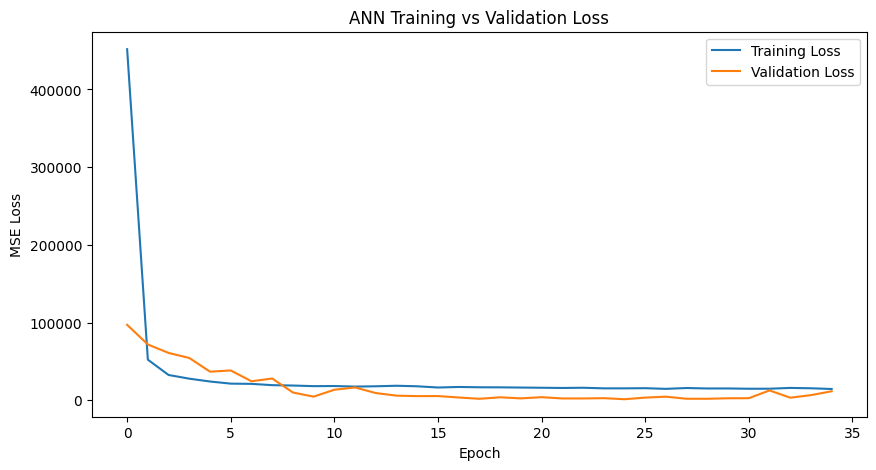

In [43]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("ANN Training vs Validation Loss")
plt.legend()

plt.show()

In [45]:
y_pred = model.predict(X_test_Scaled)


41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


In [46]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 112.99213410603024
RMSE: 152.85055616769662
R²: 0.9752836885158541
